In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))


if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\Win 10\Desktop\Math for ML Engineering projects\stock_prediction


In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

In [4]:
from src.config import ERROR_PATH

df = pd.read_csv(ERROR_PATH)

In [5]:
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand,day_of_week,day_of_month,week_of_year,month,quarter,demand_lag_1,demand_lag_7,demand_lag_14,demand_rolling_mean_7,demand_rolling_mean_14,demand_change_1,actual_demand,predicted_demand,error,absolute_error
0,2023-10-13,S001,P0001,Electronics,North,279,34,0,55.13,10,Snowy,0,54.38,Autumn,1,38,4,13,41,10,4,49.00,80.00,107.00,54.14,77.50,-31.00,38,42.97,-4.97,4.97
1,2023-10-13,S001,P0002,Clothing,North,149,63,114,65.21,0,Snowy,0,70.84,Autumn,1,95,4,13,41,10,4,141.00,97.00,151.00,127.86,130.43,44.00,95,88.83,6.17,6.17
2,2023-10-13,S001,P0003,Clothing,North,175,45,0,48.09,5,Snowy,0,45.40,Autumn,1,57,4,13,41,10,4,76.00,174.00,91.00,122.00,118.21,-98.00,57,59.86,-2.86,2.86
3,2023-10-13,S001,P0004,Electronics,North,220,49,0,76.25,15,Snowy,1,85.60,Autumn,1,44,4,13,41,10,4,57.00,146.00,99.00,75.00,81.29,-89.00,44,51.34,-7.34,7.34
4,2023-10-13,S001,P0005,Groceries,North,318,67,0,47.19,15,Snowy,1,52.77,Autumn,1,79,4,13,41,10,4,102.00,88.00,168.00,72.71,93.21,14.00,79,78.79,0.21,0.21


In [7]:
df.shape

(11000, 31)

In [8]:
df.isnull().sum()

Date                      0
Store ID                  0
Product ID                0
Category                  0
Region                    0
Inventory Level           0
Units Sold                0
Units Ordered             0
Price                     0
Discount                  0
Weather Condition         0
Promotion                 0
Competitor Pricing        0
Seasonality               0
Epidemic                  0
Demand                    0
day_of_week               0
day_of_month              0
week_of_year              0
month                     0
quarter                   0
demand_lag_1              0
demand_lag_7              0
demand_lag_14             0
demand_rolling_mean_7     0
demand_rolling_mean_14    0
demand_change_1           0
actual_demand             0
predicted_demand          0
error                     0
absolute_error            0
dtype: int64

In [10]:
df.dtypes

Date                       object
Store ID                   object
Product ID                 object
Category                   object
Region                     object
Inventory Level             int64
Units Sold                  int64
Units Ordered               int64
Price                     float64
Discount                    int64
Weather Condition          object
Promotion                   int64
Competitor Pricing        float64
Seasonality                object
Epidemic                    int64
Demand                      int64
day_of_week                 int64
day_of_month                int64
week_of_year                int64
month                       int64
quarter                     int64
demand_lag_1              float64
demand_lag_7              float64
demand_lag_14             float64
demand_rolling_mean_7     float64
demand_rolling_mean_14    float64
demand_change_1           float64
actual_demand               int64
predicted_demand          float64
error         

In [11]:
df["Date"] = pd.to_datetime(df["Date"])

df["error"] = df["actual_demand"] - df["predicted_demand"]
df["absolute_error"] = df["error"].abs()

df["percentage_error"] = (
    df["absolute_error"] / df["actual_demand"].replace(0, np.nan)
) * 100

df["day_of_week"] = df["Date"].dt.day_name()
df["day_number"] = df["Date"].dt.dayofweek

df["month"] = df["Date"].dt.month
df["month_name"] = df["Date"].dt.month_name()

df["year"] = df["Date"].dt.year

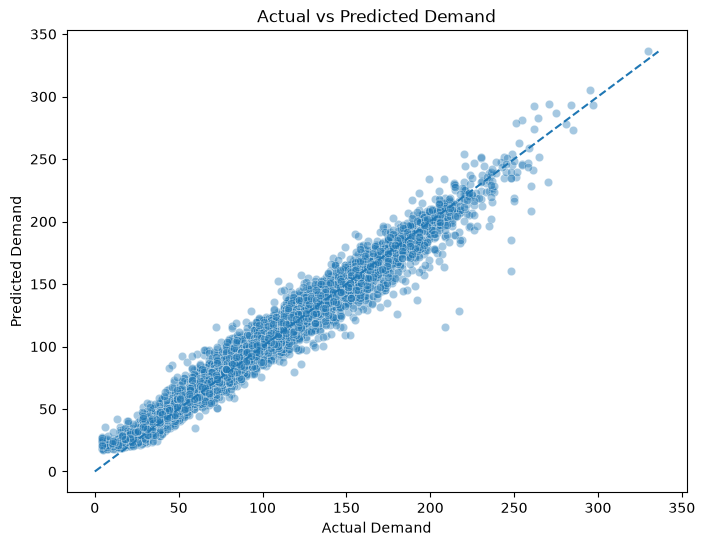

In [12]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="actual_demand",
    y="predicted_demand",
    alpha=0.4
)

max_value = max(
    df["actual_demand"].max(),
    df["predicted_demand"].max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand")

plt.show()

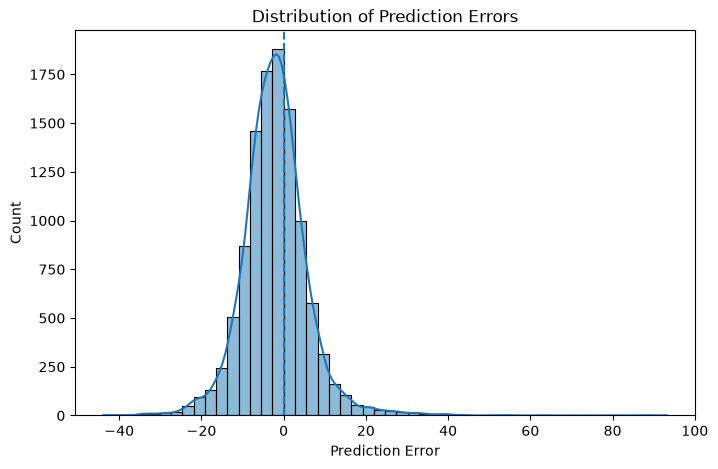

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["error"],
    bins=50,
    kde=True
)

plt.axvline(0, linestyle="--")

plt.xlabel("Prediction Error")
plt.title("Distribution of Prediction Errors")

plt.show()

In [15]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

mae_day = (
    df.groupby("day_of_week")["absolute_error"]
    .mean()
    .reindex(day_order)
)

mae_day

day_of_week
Monday      5.94
Tuesday     5.87
Wednesday   6.11
Thursday    6.24
Friday      6.07
Saturday    6.11
Sunday      6.10
Name: absolute_error, dtype: float64

In [17]:
mae_month = (
    df.groupby("month")["absolute_error"]
    .mean()
)

mae_month

month
1    6.03
10   5.79
11   5.97
12   6.34
Name: absolute_error, dtype: float64

In [36]:
mae_product = (
    df.groupby("Product ID")
    .agg(
        MAE=("absolute_error", "mean"),
        Mean_Error=("error", "mean"),
        Count=("error", "size")
    )
    .sort_values("MAE", ascending=False)
)

mae_product

,MAE,Mean_Error,Count
Product ID,,,
P0001,9.08,-1.65,550
P0004,8.83,-2.37,550
P0007,8.40,-1.80,550
P0005,7.30,-3.56,550
P0002,6.95,-3.78,550
P0010,6.82,-1.45,550
P0013,6.80,-1.29,550
P0018,6.41,-0.21,550
P0017,6.13,-1.63,550


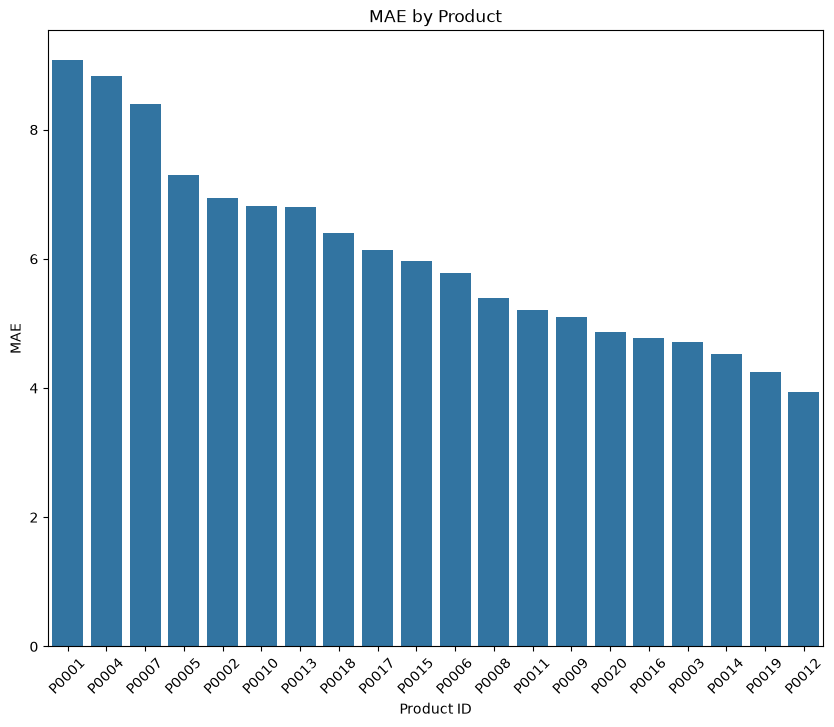

In [23]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=mae_product.reset_index(),
    x="Product ID",
    y="MAE"
)

plt.xticks(rotation=45)
plt.ylabel("MAE")
plt.title("MAE by Product")

plt.show()

In [25]:
store_category_mae = pd.pivot_table(
    df,
    values="absolute_error",
    index="Category",
    columns="Store ID",
    aggfunc="mean"
)

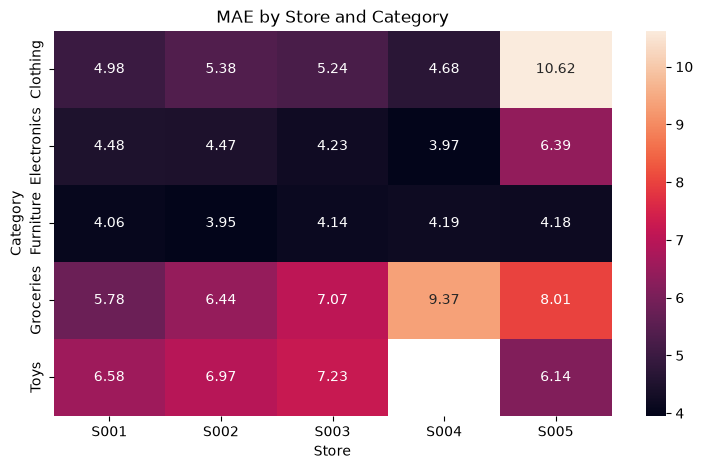

In [26]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    store_category_mae,
    annot=True,
    fmt=".2f"
)

plt.title("MAE by Store and Category")
plt.xlabel("Store")
plt.ylabel("Category")

plt.show()

In [28]:
worst = (
    df.sort_values("absolute_error", ascending=False)
    .head(30)
)

worst[
    [
        "Date",
        "Store ID",
        "Product ID",
        "Category",
        "actual_demand",
        "predicted_demand",
        "error",
        "absolute_error",
        "percentage_error"
    ]
]

,Date,Store ID,Product ID,Category,actual_demand,predicted_demand,error,absolute_error,percentage_error
10480,2024-01-25,S005,P0001,Groceries,209,115.77,93.23,93.23,44.61
9243,2024-01-13,S003,P0004,Groceries,217,128.29,88.71,88.71,40.88
4046,2023-11-22,S003,P0007,Groceries,248,160.65,87.35,87.35,35.22
10584,2024-01-26,S005,P0005,Groceries,248,185.42,62.58,62.58,25.23
9460,2024-01-15,S004,P0001,Groceries,192,137.44,54.56,54.56,28.42
1680,2023-10-29,S005,P0001,Groceries,180,126.33,53.67,53.67,29.82
10197,2024-01-22,S005,P0018,Clothing,260,208.67,51.33,51.33,19.74
9523,2024-01-16,S002,P0004,Groceries,208,163.78,44.22,44.22,21.26
6280,2023-12-14,S005,P0001,Groceries,72,115.85,-43.85,43.85,60.90
6784,2023-12-19,S005,P0005,Groceries,109,152.27,-43.27,43.27,39.70


In [29]:
worst_groups = (
    df.assign(
        is_large_error=df["absolute_error"] >= 20
    )
    .groupby(["Store ID", "Category"])
    .agg(
        Total_Rows=("error", "size"),
        Large_Errors=("is_large_error", "sum"),
        MAE=("absolute_error", "mean")
    )
)

worst_groups["Large_Error_Rate"] = (
    worst_groups["Large_Errors"] /
    worst_groups["Total_Rows"]
)

worst_groups.sort_values(
    "Large_Error_Rate",
    ascending=False
)

Total_Rows  Large_Errors   MAE  Large_Error_Rate
Store ID Category                                                     
S005     Clothing            110            16 10.62              0.15
S004     Groceries           770            71  9.37              0.09
S005     Groceries          1100            88  8.01              0.08
S003     Groceries           990            47  7.07              0.05
         Toys                330            12  7.23              0.04
S002     Groceries           880            30  6.44              0.03
S005     Electronics         220             6  6.39              0.03
S002     Toys                330             8  6.97              0.02
         Clothing            550            10  5.38              0.02
S005     Toys                440             8  6.14              0.02
S001     Toys                440             7  6.58              0.02
         Groceries           660             9  5.78              0.01
S002     Furniture           110             1  3.95              0.01
S004     Clothing            550             3  4.68              0.01
         Furniture           770             4  4.19              0.01
S002     Electronics         330             1  4.47              0.00
S005     Furniture           330             0  4.18              0.00
S001     Clothing            330             0  4.98              0.00
S004     Electronics         110             0  3.97              0.00
S001     Electronics         330             0  4.48              0.00
S003     Electronics         330             0  4.23              0.00
         Clothing            220             0  5.24              0.00
S001     Furniture           440             0  4.06              0.00
S003     Furniture           330             0  4.14              0.00

In [37]:
s005 = (
    df[df["Store ID"] == "S005"]
    .groupby(["Category", "Product ID"])
    .agg(
        MAE=("absolute_error", "mean"),
        Mean_Error=("error", "mean"),
        Count=("error", "size")
    )
    .sort_values("MAE", ascending=False)
)

s005

MAE  Mean_Error  Count
Category    Product ID                         
Groceries   P0001      14.57        0.19    110
            P0005      13.96       -6.37    110
            P0004      12.22       -5.26    110
Clothing    P0018      10.62        1.52    110
Electronics P0002       7.70       -5.44    110
Toys        P0016       6.87       -2.40    110
            P0017       6.78       -0.43    110
Groceries   P0006       6.38       -3.57    110
            P0007       6.12       -3.68    110
            P0008       5.98        0.27    110
Toys        P0020       5.98       -3.32    110
Groceries   P0010       5.82       -2.79    110
            P0015       5.64       -2.33    110
Electronics P0011       5.07       -2.91    110
Toys        P0003       4.93       -2.95    110
Groceries   P0013       4.76       -1.48    110
            P0009       4.66       -2.18    110
Furniture   P0019       4.25       -3.17    110
            P0014       4.24       -3.05    110
            P0012       4.05       -2.17    110

In [30]:
daily_error = (
    df.groupby("Date")
    .agg(
        MAE=("absolute_error", "mean"),
        Mean_Error=("error", "mean")
    )
    .reset_index()
)

daily_error.head()

,Date,MAE,Mean_Error
0,2023-10-13,5.30,-2.60
1,2023-10-14,5.66,-2.26
2,2023-10-15,4.94,-2.26
3,2023-10-16,5.51,-3.34
4,2023-10-17,5.78,-2.62


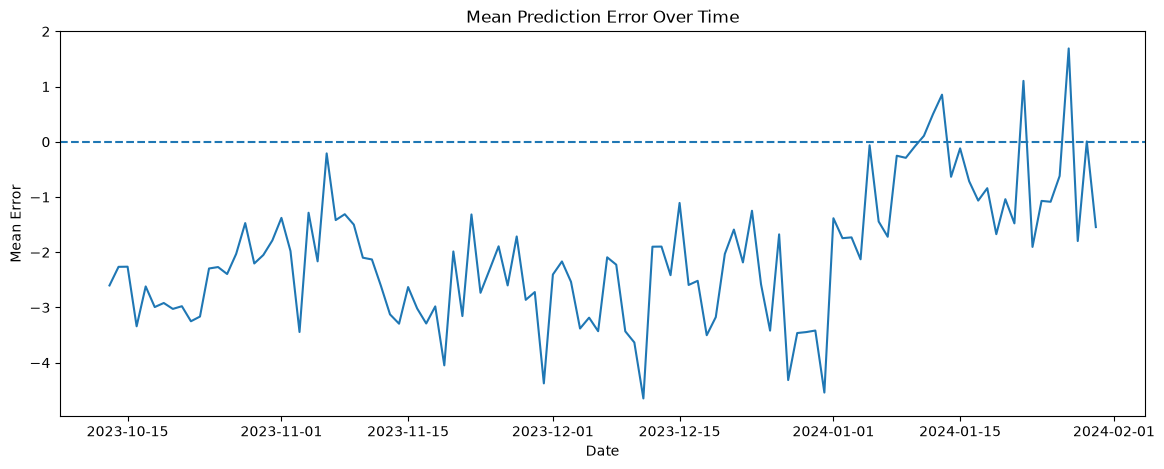

In [31]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_error["Date"],
    daily_error["Mean_Error"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Date")
plt.ylabel("Mean Error")
plt.title("Mean Prediction Error Over Time")

plt.show()

In [32]:
s005_daily = (
    df[df["Store ID"] == "S005"]
    .groupby("Date")
    .agg(
        Actual=("actual_demand", "sum"),
        Predicted=("predicted_demand", "sum"),
        MAE=("absolute_error", "mean")
    )
    .reset_index()
)

s005_daily.head()

,Date,Actual,Predicted,MAE
0,2023-10-13,1184,1226.33,5.53
1,2023-10-14,1145,1209.78,6.69
2,2023-10-15,1238,1338.46,6.68
3,2023-10-16,1195,1274.66,6.60
4,2023-10-17,1492,1570.12,6.12


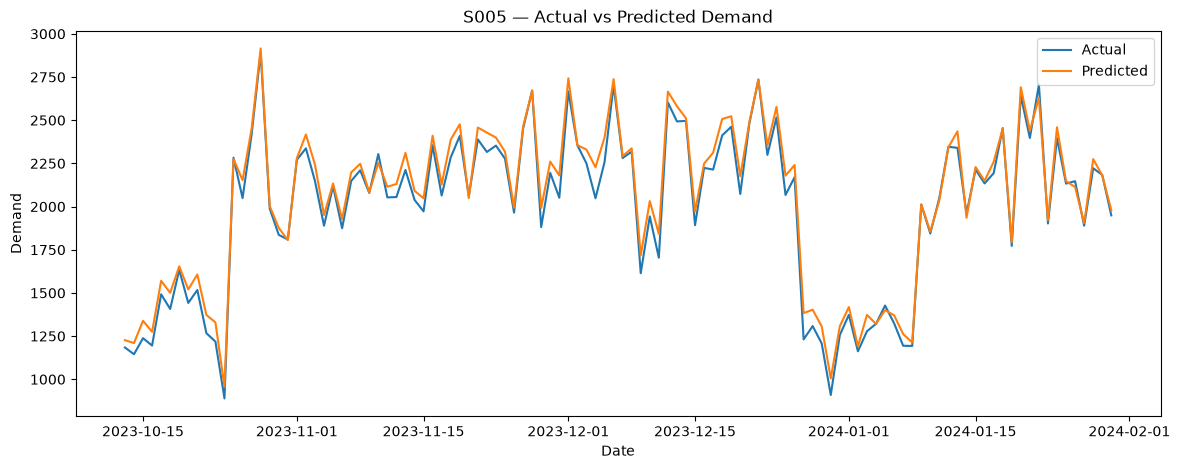

In [33]:
plt.figure(figsize=(14, 5))

plt.plot(
    s005_daily["Date"],
    s005_daily["Actual"],
    label="Actual"
)

plt.plot(
    s005_daily["Date"],
    s005_daily["Predicted"],
    label="Predicted"
)

plt.xlabel("Date")
plt.ylabel("Demand")
plt.title("S005 — Actual vs Predicted Demand")

plt.legend()

plt.show()